# 04 — Feature Engineering

Demonstrates `src.feature_engineering`: power transforms for skewed data, filter/wrapper/
embedded feature selection, and PCA — using the house price dataset's deliberately
redundant/noisy columns (`area_sqft_copy`, `random_noise_1`, `random_noise_2`).

In [1]:
import sys
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.data.loader import load_data
from src.data.splitter import split_data
from src.preprocessing.numerical import build_numeric_pipeline
from src.feature_engineering.transformation import build_power_transformer
from src.feature_engineering.selection import select_k_best, rfe_selector, select_from_model, lasso_selector, check_nonnegative_for_chi2
from src.feature_engineering.dimensionality_reduction import build_pca_pipeline
from src.models.factory import get_model

## Load data

In [2]:
df = load_data("../data/raw/house_prices.csv")
numeric_cols = ["area_sqft", "bedrooms", "age_years", "distance_to_city_km",
                "area_sqft_copy", "random_noise_1", "random_noise_2"]
X = df[numeric_cols]
y = df["price"]

[07:09:48] INFO     src.data.loader: Loaded 'house_prices.csv' as csv -> shape=(500, 10)


DATA SUMMARY
Rows: 500   Columns: 10
Duplicate rows: 0

Dtypes:
float64    7
int64      2
object     1

Missing values: none


## Power transformation

`age_years` is right-skewed (many newer houses, a long tail of very old ones). We fix that
with a Yeo-Johnson transform and compare the distribution before and after.

Skewness of age_years before transform: 1.696
Skewness of age_years after transform:  -0.019


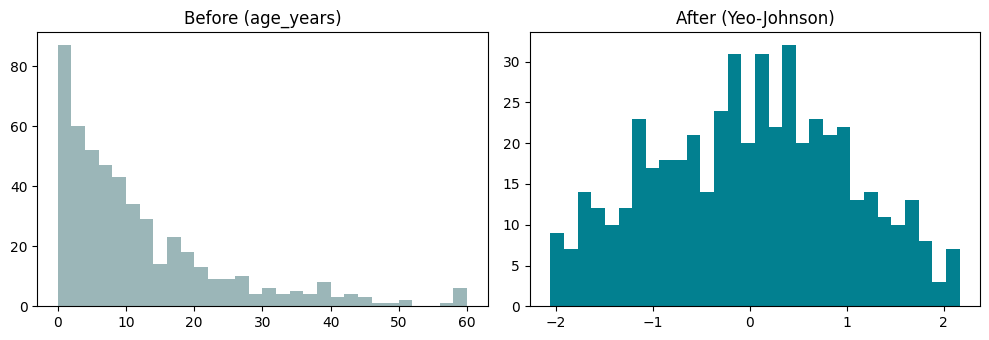

In [3]:
print(f"Skewness of age_years before transform: {df['age_years'].skew():.3f}")

power_transformer = build_power_transformer(method="yeo-johnson")
age_transformed = power_transformer.fit_transform(df[["age_years"]])

print(f"Skewness of age_years after transform:  {pd.Series(age_transformed.ravel()).skew():.3f}")

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].hist(df["age_years"], bins=30, color="#9BB6B8")
axes[0].set_title("Before (age_years)")
axes[1].hist(age_transformed, bins=30, color="#028090")
axes[1].set_title("After (Yeo-Johnson)")
plt.tight_layout()
plt.show()

---
## Feature selection

We now bring in the redundant (`area_sqft_copy`) and pure-noise (`random_noise_1`,
`random_noise_2`) columns on purpose, so each selection method has real problems to solve.

In [4]:
# Rescale price into thousands (same reason as notebook 02: keeps the target on a
# numerically friendly scale for methods that involve regularization/coordinate descent)
X_full = df[numeric_cols]
y_full = df["price"] / 1000

scaler_pipe = build_numeric_pipeline(imputation="median", scaling="standard")
X_scaled = scaler_pipe.fit_transform(X_full)

### Filter method — SelectKBest

In [5]:
filter_selector = select_k_best(task="regression", score_func="f_regression", k=4)
filter_selector.fit(X_scaled, y_full)

scores = pd.Series(filter_selector.scores_, index=numeric_cols).sort_values(ascending=False)
print("f_regression scores (higher = more related to price):")
print(scores)
print("\nSelected (top 4):", list(np.array(numeric_cols)[filter_selector.get_support()]))

f_regression scores (higher = more related to price):
area_sqft_copy         205.950792
area_sqft              203.648851
bedrooms                21.123846
distance_to_city_km      5.768595
random_noise_2           2.064728
age_years                1.432638
random_noise_1           0.571200
dtype: float64

Selected (top 4): [np.str_('area_sqft'), np.str_('bedrooms'), np.str_('distance_to_city_km'), np.str_('area_sqft_copy')]


**Why not chi-square here?** Our scaled features contain negative values (that's what
standardization does), and chi-square is only valid for non-negative data. Calling it
directly raises a clear, actionable error rather than silently producing nonsense:

In [6]:
try:
    check_nonnegative_for_chi2(X_scaled)
except ValueError as e:
    print("Caught expected error:")
    print(e)

Caught expected error:
chi2 requires all feature values to be non-negative (it's a test built on counts/frequencies). Your data contains negative values -- this usually means it's already been standardized/scaled. Either select features BEFORE scaling, or use score_func='f_classif' / 'mutual_info_classif' instead.


### Wrapper method — Recursive Feature Elimination (RFE)

In [7]:
rfe = rfe_selector(get_model("linear"), n_features_to_select=4)
rfe.fit(X_scaled, y_full)

ranking = pd.Series(rfe.ranking_, index=numeric_cols).sort_values()
print("RFE ranking (1 = selected, higher = eliminated earlier):")
print(ranking)
print("\nSelected:", list(np.array(numeric_cols)[rfe.support_]))

[07:09:48] INFO     src.models.factory: Created model: linear -> LinearRegression({})


RFE ranking (1 = selected, higher = eliminated earlier):
area_sqft              1
bedrooms               1
distance_to_city_km    1
area_sqft_copy         1
random_noise_2         2
random_noise_1         3
age_years              4
dtype: int64

Selected: [np.str_('area_sqft'), np.str_('bedrooms'), np.str_('distance_to_city_km'), np.str_('area_sqft_copy')]


### Embedded method — Lasso-based selection

In [8]:
embedded_selector = lasso_selector(alpha=5.0)
embedded_selector.fit(X_scaled, y_full)

selected_embedded = list(np.array(numeric_cols)[embedded_selector.get_support()])
print("Lasso-selected features:", selected_embedded)
print("\nDropped:", [f for f in numeric_cols if f not in selected_embedded])

Lasso-selected features: [np.str_('bedrooms'), np.str_('distance_to_city_km'), np.str_('area_sqft_copy')]

Dropped: ['area_sqft', 'age_years', 'random_noise_1', 'random_noise_2']


**What to notice across all three:** every method drops `random_noise_1` and
`random_noise_2` — no genuine signal, easy call. The more interesting, honest finding is in
the collinear pair `area_sqft` / `area_sqft_copy`: BOTH the filter method AND RFE keep both
columns (filter scores each column independently so it can't see the redundancy at all; RFE
here ends up doing the same, since with two near-identical, similarly strong predictors,
removing either one barely changes the linear model's fit at each elimination step, so RFE
has little basis to prefer one over the other). Only the EMBEDDED Lasso method actually
breaks the tie, dropping `area_sqft` entirely and keeping just `area_sqft_copy` — its L1
penalty specifically favors a SPARSE solution among correlated features, which the other two
methods have no equivalent mechanism for. The lesson: "wrapper methods handle redundancy
better than filter methods" is true in general, but not automatically — it depends on
whether the wrapper's underlying model actually penalizes redundancy, which plain Linear
Regression does not.

---
## Dimensionality reduction — PCA

`build_pca_pipeline()` scales first, then applies PCA — the module's WHY note explains why
that order is non-negotiable. We keep enough components to explain 95% of the variance and
see how many that turns out to be.

In [9]:
pca_pipeline = build_pca_pipeline(n_components=0.95)
X_pca = pca_pipeline.fit_transform(X_full)

pca_step = pca_pipeline.named_steps["pca"]
print(f"Started with {X_full.shape[1]} raw features")
print(f"Kept {pca_step.n_components_} components to explain 95% of variance")
print(f"Explained variance ratio per component: {pca_step.explained_variance_ratio_.round(3)}")
print(f"Cumulative: {pca_step.explained_variance_ratio_.cumsum().round(3)}")

Started with 7 raw features
Kept 6 components to explain 95% of variance
Explained variance ratio per component: [0.286 0.164 0.15  0.145 0.134 0.12 ]
Cumulative: [0.286 0.45  0.6   0.746 0.88  1.   ]


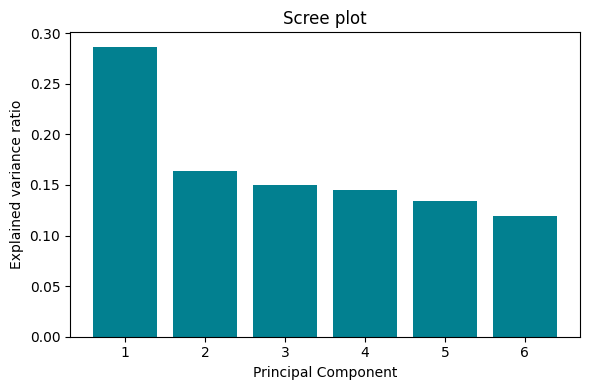

In [10]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(range(1, len(pca_step.explained_variance_ratio_) + 1), pca_step.explained_variance_ratio_,
       color="#028090")
ax.set_xlabel("Principal Component")
ax.set_ylabel("Explained variance ratio")
ax.set_title("Scree plot")
plt.tight_layout()
plt.show()

**An honest, more nuanced finding than you might expect:** PCA only compressed 7 raw
columns down to 6 components — barely any reduction at all. Checking the correlation matrix
explains exactly why: `area_sqft` and `area_sqft_copy` are perfectly correlated (1.00), but
EVERY other pair of columns — including both noise columns — has essentially zero
correlation with everything else. PCA can only compress away genuinely REDUNDANT (correlated)
variance; `random_noise_1` and `random_noise_2` are pure noise from a PREDICTIVE standpoint
(recall the selection methods above correctly dropped both), but each still carries its own
independent, uncorrelated variance that PCA has no way to identify as "unimportant" and
discard — PCA only ever looks at TOTAL variance, never at the target `y`.

**This is the key distinction between PCA and feature selection:** feature selection
(Lasso/RFE above) asks "does this feature help predict the target?" and confidently drops
noise columns that don't. PCA asks only "how much of the total variance does this direction
explain?" — a column can be 100% useless for prediction and still force PCA to keep an extra
component, simply because it varies independently of everything else. Neither approach is
"better" in general; they answer genuinely different questions, and this dataset happens to
make the difference between them concrete rather than theoretical.

## Summary

This notebook covered every piece of `src.feature_engineering`: power transforms for skewed
data, three families of feature selection (filter/wrapper/embedded) compared honestly on the
same redundant/noisy dataset, and PCA — all through the same reusable functions used
throughout this framework.